In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

In [2]:
from pathlib import Path
save_dir = Path("../pics/circle_node/xavier_normal/zero_aug_T=1")
save_dir.mkdir(parents=True, exist_ok=True)

import sys
import os
sys.path.append(os.path.abspath("../"))

from src.lyap import NN_LyapExp
from src.networks import NeuralODEClassifier, NeuralODE_Truncated, init_weights
from src.utils import lyapunov_autograd, train

In [3]:
from matplotlib.colors import LinearSegmentedColormap

tf_playground = LinearSegmentedColormap.from_list(
    "tf_playground",
    [
        "#f4a261", # orange
        "#ffffff", # white
        "#2a9df4"  # blue
    ]
)

In [4]:
data = np.load("circle_dataset_eps0p01.npz")

X_train = data["X"]
y_train = data["y"]
# epsilon = data["epsilon"]

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_standardized = (X_train - mean)/std

In [5]:
data = np.load("circle_dataset_eps0p01_val.npz")

X_val = data["X"]
y_val = data["y"]

X_val_standardized = (X_val - mean)/std

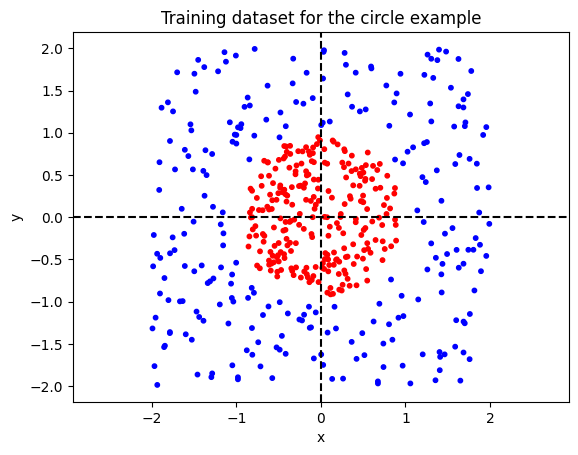

In [6]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap="bwr_r", s=10)
plt.axvline(0.0, color="k", linestyle="--")
plt.axhline(0.0, color="k", linestyle="--")
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")
plt.title("Training dataset for the circle example")
plt.show()

In [7]:
print(len(y_train))

500


In [8]:
X_train_standardized = torch.tensor(X_train_standardized, dtype=torch.float32).float()
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).float()  # add dimension if needed

X_val_standardized = torch.tensor(X_val_standardized, dtype=torch.float32).float()
y_val = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_standardized, y_train)
val_ds = TensorDataset(X_val_standardized, y_val)

train_dataloader = DataLoader(train_ds, batch_size=64)
val_dataloader = DataLoader(val_ds, batch_size=64)

In [ ]:
M = 10
seeds = [45]
# seeds = [11]

radii = np.linspace(0.2, 1.8, 40)
loss_fn = nn.MSELoss()

In [10]:
def point_generator(radius, n=32):
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)

In [11]:
T = 1.0
all_LEs = []
all_LEs_min = []
for seed in seeds:
    torch.manual_seed(seed)

    neural_ode = NeuralODEClassifier(input_dim=2, hidden_dim=3)
    neural_ode.apply(lambda m: init_weights(m, init_type="gaussian", gain=0.9))

    train(neural_ode, train_dataloader, val_dataloader, loss_fn, acc_target=0.95, seed=seed, epochs=5000)

    run_LEs = []
    run_LEs_min = []

    neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

#     for r in radii:
#         X = point_generator(r, n=32)
#         X = torch.tensor(X, dtype=torch.float32)

#         le_r, le_rmin = lyapunov_autograd(X[0, :], X[1, :], neural_ode_trunc, mean, std, T=T)

#         run_LEs.append(le_r.mean())
#         run_LEs_min.append(le_rmin.mean())

#     all_LEs.append(run_LEs)
#     all_LEs_min.append(run_LEs_min)

# all_LEs = np.array(all_LEs)
# all_LEs_min = np.array(all_LEs_min) 

Epoch 0 | Train Loss 48420.841625 | Validation Accuracy 0.500000
Epoch 20 | Train Loss 36.600568 | Validation Accuracy 0.512000
Epoch 40 | Train Loss -4.462408 | Validation Accuracy 0.516000
Epoch 60 | Train Loss -6.240760 | Validation Accuracy 0.500000
Epoch 80 | Train Loss -6.281837 | Validation Accuracy 0.500000
Epoch 100 | Train Loss -6.291677 | Validation Accuracy 0.500000
Epoch 120 | Train Loss -6.295044 | Validation Accuracy 0.500000
Epoch 140 | Train Loss -6.296869 | Validation Accuracy 0.500000
Epoch 160 | Train Loss -6.298229 | Validation Accuracy 0.500000
Epoch 180 | Train Loss -6.299418 | Validation Accuracy 0.500000
Epoch 200 | Train Loss -6.300487 | Validation Accuracy 0.500000
Epoch 220 | Train Loss -6.301460 | Validation Accuracy 0.500000
Epoch 240 | Train Loss -6.302370 | Validation Accuracy 0.500000
Epoch 260 | Train Loss -6.303208 | Validation Accuracy 0.500000
Epoch 280 | Train Loss -6.303972 | Validation Accuracy 0.500000
Epoch 300 | Train Loss -6.304690 | Validati

KeyboardInterrupt: 

In [ ]:
# all_LEs = np.where(np.isfinite(all_LEs), all_LEs, np.nan)
# mean_le = np.nanmean(all_LEs, axis=0)
# std_le = np.nanstd(all_LEs, axis=0)

# plt.plot(radii, mean_le, label="Mean FTLE")
# plt.fill_between(radii, mean_le-std_le, mean_le+std_le, alpha=0.3)
# plt.axhline(0, linestyle="--", color="black")
# plt.axvline(1.0, linestyle=":", color="red", label="Boundary")
# plt.legend()
# plt.xlabel("Radius")
# plt.ylabel("Largest Lyapunov Exponent")

In [ ]:
# all_LEs_min = np.where(np.isfinite(all_LEs_min), all_LEs_min, np.nan)
# mean_le_min = np.nanmean(all_LEs_min, axis=0)
# std_le_min = np.nanstd(all_LEs_min, axis=0)

# plt.plot(radii, mean_le_min, label="Mean FTLE")
# plt.fill_between(radii, mean_le_min-std_le_min, mean_le_min+std_le_min, alpha=0.3)
# plt.axhline(0, linestyle="--", color="black")
# plt.axvline(1.0, linestyle=":", color="red", label="Boundary")
# plt.legend()
# plt.xlabel("Radius")
# plt.ylabel("Smallest FT Lyapunov Exponent")

In [ ]:
x_vals = np.linspace(-2, 2, 50)  # Make it 50 to improve time it takes
y_vals = np.linspace(-2, 2, 50)

t0 = 0.0
# t1_list = np.linspace(0.01, 1.0, 20)
t1 = 1.0

In [ ]:
# lyap_grid_list = []
# lyap_grid_min_list = []
# for t1 in t1_list:
lyap_grid = np.zeros((len(x_vals), len(y_vals)))
lyap_grid_min = np.zeros_like(lyap_grid)

neural_ode_trunc = NeuralODE_Truncated(neural_ode_model=neural_ode)

nn_lyap = NN_LyapExp(neural_ode_trunc)

for i, x in enumerate(x_vals):
    for j, y in enumerate(y_vals):

        # Create 1×2 input
        x0 = torch.tensor([[x, y]], dtype=torch.float32)

        # Standardize using your saved statistics
        x0 = ((x0 - mean) / std).float()

        # Compute Jacobian
        J = nn_lyap.jacobian_flow(x0, t0=t0, t1=t1)

        # Singular values
        svals = torch.linalg.svdvals(J)

        # Largest Lyapunov proxy
        lyap_grid[j, i] = (1.0/(t1-t0)) * torch.log(svals.max()).item()
        lyap_grid_min[j, i] =(1.0/(t1-t0)) * torch.log(svals.min()).item()

    # lyap_grid_list.append(lyap_grid)
    # lyap_grid_min_list.append(lyap_grid_min)

In [ ]:
# import imageio.v2 as imageio

# frames = []

# for k, lyap_grid in enumerate(lyap_grid_list):
#     fig, ax = plt.subplots(figsize=(6, 6))
#     im = ax.imshow(
#         lyap_grid,
#         extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
#         origin="lower",
#         cmap="coolwarm",
#         vmin=-3,
#         vmax=3
#     )
#     ax.set_title(f"FTLE Heatmap (t = {t1_list[k]:.2f})")
#     ax.set_xlabel("x")
#     ax.set_ylabel("y")
#     plt.colorbar(im, ax=ax)

#     fig.canvas.draw()
#     frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
#     frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
#     frames.append(frame)

#     plt.close(fig)

# imageio.mimsave("ftle_time_evolution_t1.gif", frames, fps=4)

In [ ]:
# frames = []

# for k, lyap_grid in enumerate(lyap_grid_min_list):
#     fig, ax = plt.subplots(figsize=(6, 6))
#     im = ax.imshow(
#         lyap_grid,
#         extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
#         origin="lower",
#         cmap="coolwarm",
#         vmin=-3,
#         vmax=3
#     )
#     ax.set_title(f"Second FTLE Heatmap (t = {t1_list[k]:.2f})")
#     ax.set_xlabel("x")
#     ax.set_ylabel("y")
#     plt.colorbar(im, ax=ax)

#     fig.canvas.draw()
#     frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
#     frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
#     frames.append(frame)

#     plt.close(fig)

# imageio.mimsave("ftle_time_evolution_min_t1.gif", frames, fps=4)

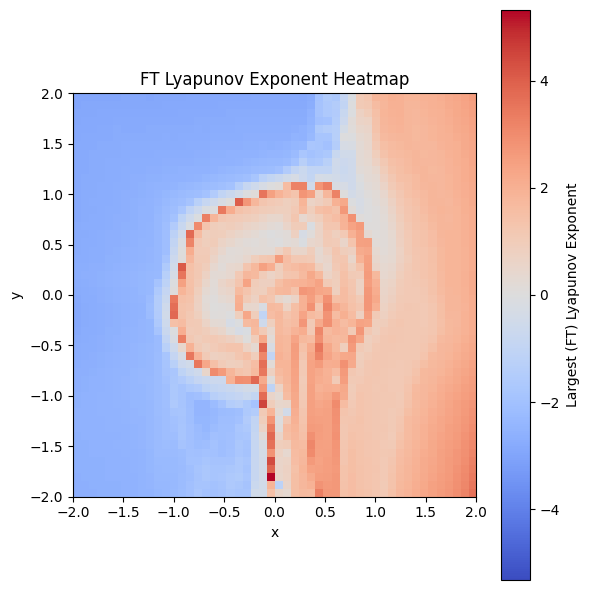

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

v = np.max(np.abs(lyap_grid))

im = ax.imshow(
    lyap_grid,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',
    vmin=-v,
    vmax=v
)

fig.colorbar(im, ax=ax, label="Largest (FT) Lyapunov Exponent")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("FT Lyapunov Exponent Heatmap")

fig.tight_layout()

fig.savefig(save_dir / "paper_dopri_ce_relu_1ftle_45", dpi=300, bbox_inches='tight')

plt.show()

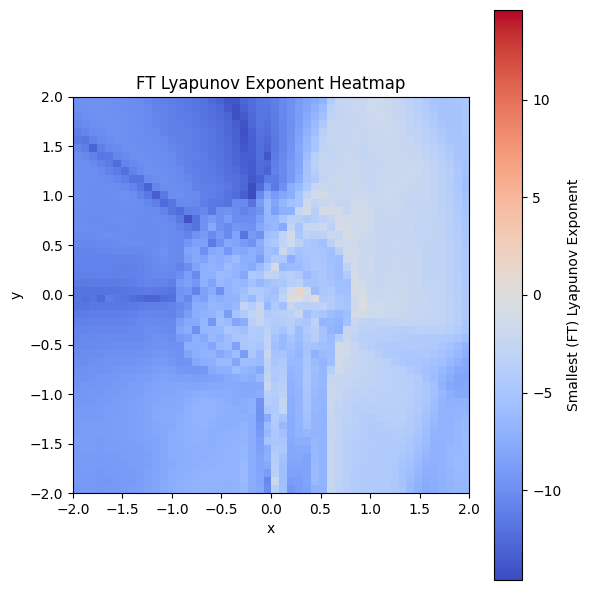

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

v = np.max(np.abs(lyap_grid_min))

im = ax.imshow(
    lyap_grid_min,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap='coolwarm',
    vmin=-v,
    vmax=v
)

fig.colorbar(im, ax=ax, label="Smallest (FT) Lyapunov Exponent")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("FT Lyapunov Exponent Heatmap")

fig.tight_layout()

fig.savefig(save_dir / "paper_dopri_ce_relu_2ftle_45.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
X, Y = np.meshgrid(x_vals, y_vals)

points = np.stack([X.ravel(), Y.ravel()], axis=1)
points_t = torch.tensor(points, dtype=torch.float32)

points_t = ((points_t - mean) / std).float()

neural_ode.eval()
with torch.no_grad():
    preds = neural_ode(points_t).cpu().numpy()

Z = preds.reshape(len(x_vals), len(y_vals))

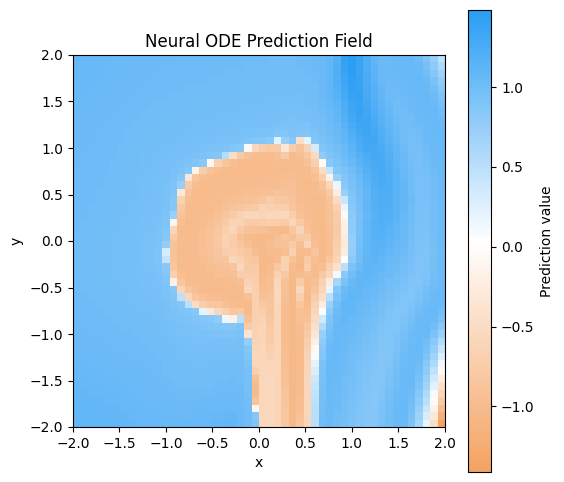

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    Z,
    extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
    origin='lower',
    cmap=tf_playground,
)

fig.colorbar(im, ax=ax, label="Prediction value")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Neural ODE Prediction Field")


fig.savefig(save_dir / "paper_dopri_ce_relu_pred_45.png", dpi=300)

plt.show()

In [ ]:
Y_true = np.where(X**2 + Y**2 < 1, -1, 1)

Z = preds.reshape(len(y_vals), len(x_vals))
Y_pred = np.where(Z < 0, -1, 1)

accuracy = (Y_pred.flatten() == Y_true.flatten()).mean()
print("Accuracy:", accuracy)

Accuracy: 0.9344


In [ ]:
t_eval = torch.linspace(0, 1, 100)

with torch.no_grad():
    traj = neural_ode.get_hidden_trajectory(points_t, t_eval) # Shape time_steps, num_points, 3

In [ ]:
x_colors = points_t[:, 0]
y_colors = points_t[:, 1]

labels = torch.where((x_colors**2 + y_colors**2)<=1, -1, 1)

colors = torch.zeros((points_t.shape[0], 3)) # RGB

# Red if the point is inside the circle
colors[labels == -1] = torch.tensor([1.0, 0.0, 0.0])

# Blue if the point is outside the circle
colors[labels == 1] = torch.tensor([0.0, 0.0, 1.0])
colors_np = colors.numpy()

Saved GIF: xavier_normal_hidden_flow_42.gif


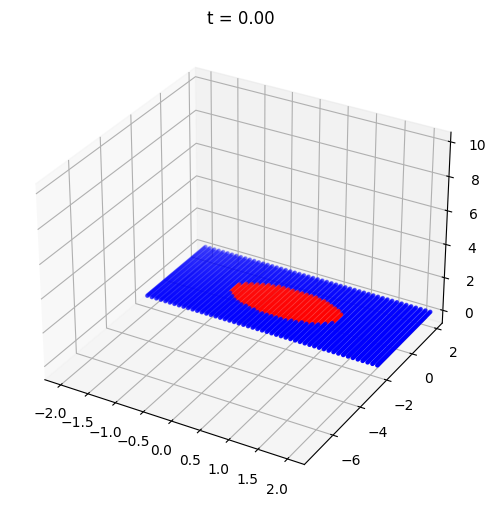

In [ ]:
from matplotlib.animation import FuncAnimation
# matplotlib.use("Agg")

T, N, _ = traj.shape
traj_np = traj.cpu().numpy()

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Initial scatter
scatter = ax.scatter(traj_np[0,:,0], traj_np[0,:,1], traj_np[0,:,2], c=colors_np, s=5)

ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())
# ax.set_title("Neural ODE flow in hidden space"

def update(frame):
    scatter._offsets3d = (
        traj_np[frame,:,0],
        traj_np[frame,:,1],
        traj_np[frame,:,2],
    )
    ax.set_title(f"t = {1*frame/(T-1):.2f}")
    return scatter,

anim = FuncAnimation(fig, update, frames=T, interval=80)

anim.save("../pics/circle_node/xavier_normal/zero_aug_T=1/paper_dopri_ce_relu_hidden_flow_45.gif", writer="pillow", fps=15)
print("Saved GIF: xavier_normal_hidden_flow_42.gif")

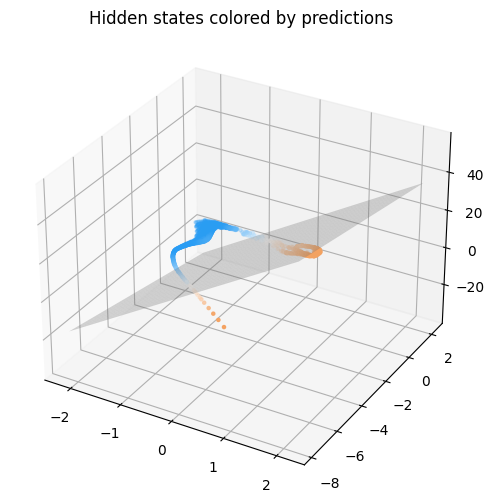

In [ ]:
# Z is shape (len(x_vals), len(y_vals)), e.g., (100,100)
Z_flat = Z.ravel()  # shape (10000,)

# Normalize predictions to [0,1] if needed
Z_norm = (Z_flat + 1) / 2  # assuming predictions in [-1,1]

# Map to colors
colors_pred = tf_playground(Z_norm)  # shape (10000, 4) 
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_pred, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()


In [ ]:
fig.savefig("../pics/circle_node/xavier_normal/zero_aug_T=1/paper_dopri_ce_relu_final_frame_pred_45.png")

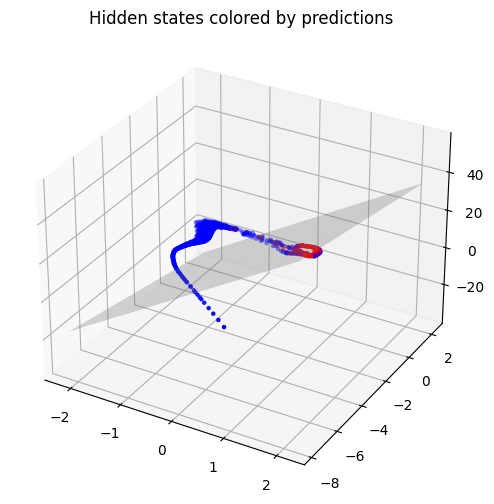

In [ ]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# Now this matches the flattened traj points
scatter = ax.scatter(traj_np[-1,:,0], traj_np[-1,:,1], traj_np[-1,:,2],
                     c=colors_np, s=5)

# ax.set_xlim(traj_np[:,:,0].min(), traj_np[:,:,0].max())
# ax.set_ylim(traj_np[:,:,1].min(), traj_np[:,:,1].max())
# ax.set_zlim(traj_np[:,:,2].min(), traj_np[:,:,2].max())

# Optional: overlay decision boundary plane
W = neural_ode.final_layer.weight.data.cpu().numpy()
b = neural_ode.final_layer.bias.data.cpu().numpy()
xx, yy = np.meshgrid(np.linspace(traj_np[:,:,0].min(), traj_np[:,:,0].max(), 30),
                     np.linspace(traj_np[:,:,1].min(), traj_np[:,:,1].max(), 30))
zz = -(W[0,0]*xx + W[0,1]*yy + b[0]) / W[0,2]

ax.plot_surface(xx, yy, zz, color='grey', alpha=0.3)

ax.set_title("Hidden states colored by predictions")
plt.show()

In [ ]:
fig.savefig("../pics/circle_node/xavier_normal/zero_aug_T=1/paper_dopri_ce_relu_final_frame_true_45.png")

In [ ]:
print(traj.std(dim=1))

tensor([[1.2311, 1.2348, 0.0000],
        [1.1980, 1.0970, 0.1008],
        [1.1647, 0.9863, 0.1904],
        [1.1302, 0.9006, 0.2664],
        [1.0950, 0.8370, 0.3286],
        [1.0594, 0.7919, 0.3800],
        [1.0232, 0.7634, 0.4248],
        [0.9871, 0.7523, 0.4650],
        [0.9526, 0.7583, 0.5016],
        [0.9192, 0.7772, 0.5345],
        [0.8864, 0.8039, 0.5638],
        [0.8531, 0.8334, 0.5903],
        [0.8183, 0.8608, 0.6144],
        [0.7824, 0.8828, 0.6360],
        [0.7464, 0.8981, 0.6552],
        [0.7117, 0.9069, 0.6726],
        [0.6800, 0.9102, 0.6884],
        [0.6521, 0.9085, 0.7031],
        [0.6287, 0.9029, 0.7170],
        [0.6098, 0.8952, 0.7306],
        [0.5955, 0.8871, 0.7439],
        [0.5851, 0.8795, 0.7570],
        [0.5778, 0.8725, 0.7698],
        [0.5730, 0.8657, 0.7826],
        [0.5702, 0.8590, 0.7954],
        [0.5688, 0.8525, 0.8085],
        [0.5685, 0.8466, 0.8220],
        [0.5687, 0.8417, 0.8360],
        [0.5690, 0.8384, 0.8506],
        [0.568